# Task
Analyze the 'telecom-customer-churn-analysis' dataset, preprocess the data, train and evaluate a churn prediction model, visualize its performance, and summarize the findings.

## Download and Extract Dataset

### Subtask:
Execute the provided `kagglehub` code to download the 'telecom-customer-churn-analysis' dataset and identify the local path to its files.


**Reasoning**:
The user wants to download a dataset using `kagglehub`. I need to import the library, download the dataset using `kagglehub.agent.download`, store the local path, and print it to complete the subtask.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/Bank_Churn_Classification_Dataset.csv')
print(df.head())

   Unnamed: 0  CustomerID  Gender  SeniorCitizen  Tenure  MonthlyCharges  \
0           0           0    Male              0      55          111.88   
1           1           1  Female              1      36           58.70   
2           2           2    Male              0      37          118.86   
3           3           3    Male              1      14           96.14   
4           4           4    Male              1      27           28.05   

         Contract     PaymentMethod  Churn  TotalCharges  
0        Two year      Mailed check      0       6153.40  
1        Two year  Electronic check      0       2113.20  
2        One year  Electronic check      0       4397.82  
3  Month-to-month      Mailed check      1       1345.96  
4        Two year      Mailed check      0        757.35  


## Exploring Specialized Visualization Tools - Pie Charts

### Subtask:
Create a pie chart to visualize the distribution of a categorical feature.

**Reasoning**:
Pie charts are effective for showing the proportion of different categories within a whole. I will create a pie chart for the 'Contract' column to visualize the distribution of contract types among customers. This will help us understand which contract types are most prevalent.

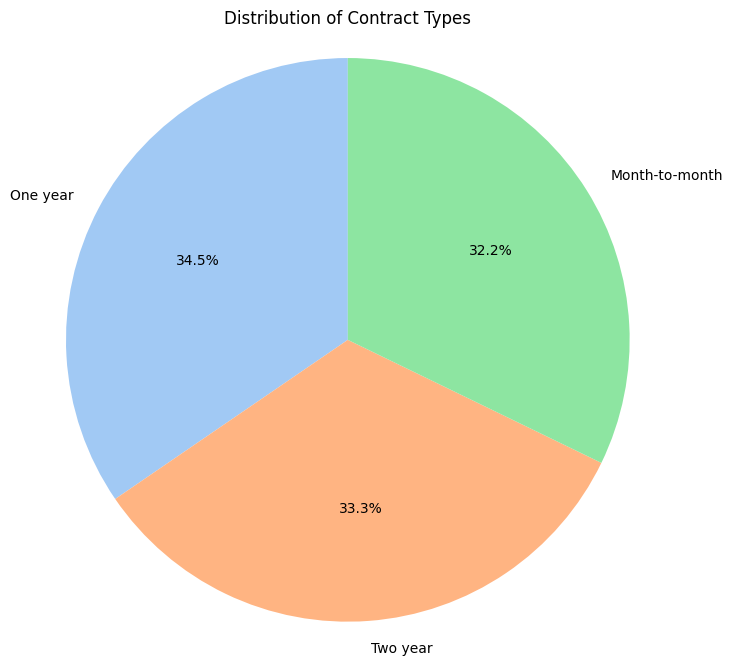

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) Create a Pie Chart for 'Contract' types
contract_counts = df['Contract'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(contract_counts, labels=contract_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Contract Types')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Exploring Bar Charts and Stacked Bar Plots

### Subtask:
Create various bar charts to visualize relationships between categorical features and the target variable (Churn).

**Reasoning**:
Bar charts are excellent for comparing categorical data. A standard bar chart can show the frequency or proportion of churn for a given category. Stacked bar plots are useful for showing the composition of a category by another variable (e.g., churn proportion within each contract type). Back-to-back bar charts can effectively compare the distributions of two related groups across different categories. I will use `Gender`, `Contract`, and `SeniorCitizen` in conjunction with `Churn` for these visualizations.

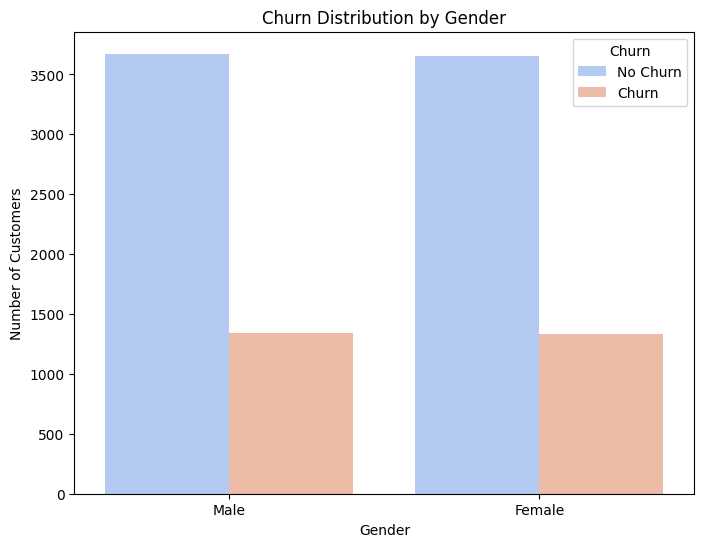

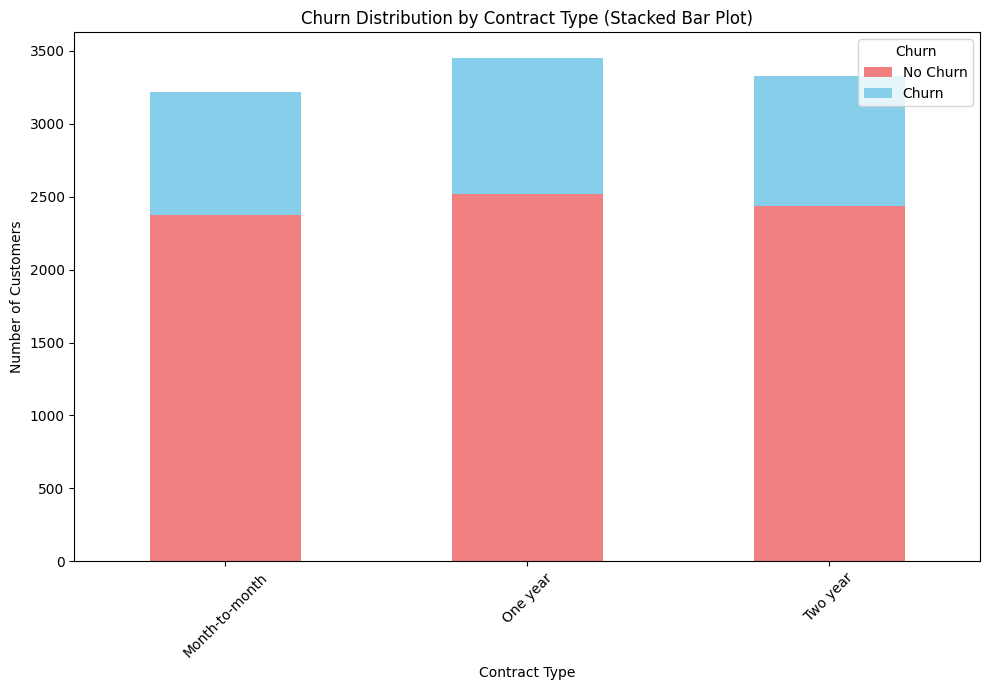

/tmp/ipython-input-3903181599.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=no_churn_senior_counts.index, y=no_churn_senior_counts.values, ax=axes[0], palette='viridis')
/tmp/ipython-input-3903181599.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_senior_counts.index, y=churn_senior_counts.values, ax=axes[1], palette='magma')


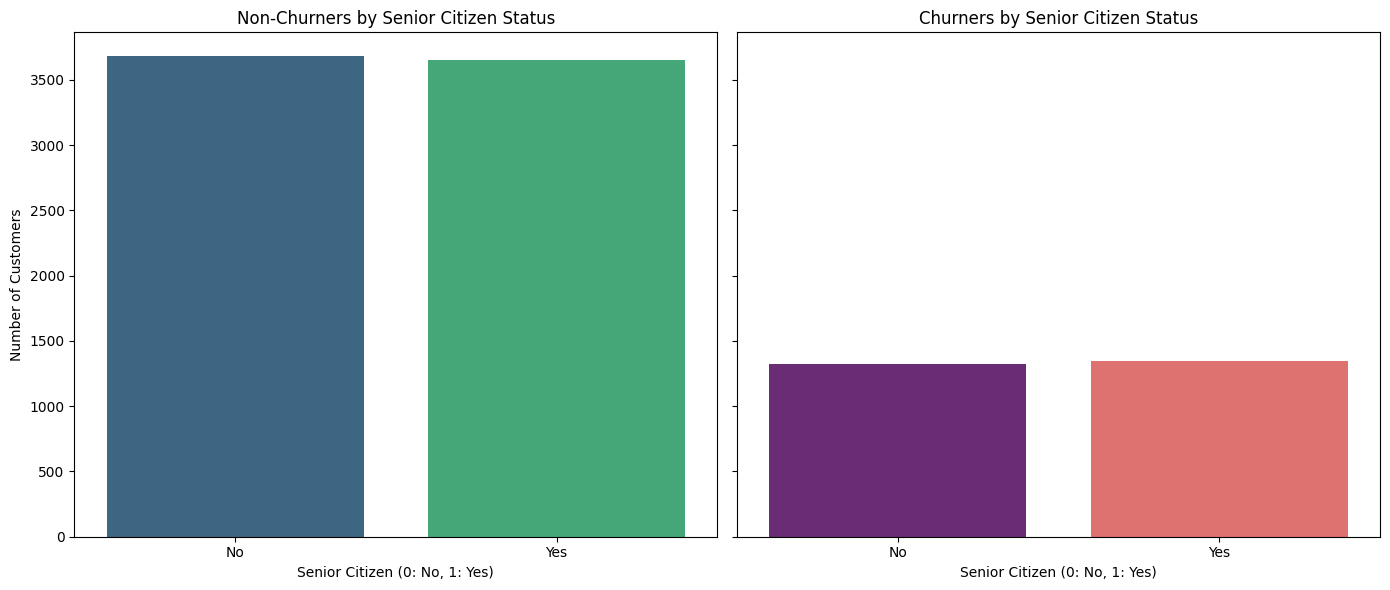

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) Bar Plot: Churn distribution by Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='Churn', data=df, palette='coolwarm')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

# b) Stacked Bar Plot: Churn distribution by Contract Type
contract_churn_counts = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn_counts.plot(kind='bar', stacked=True, figsize=(10, 7), color=['lightcoral', 'skyblue'])
plt.title('Churn Distribution by Contract Type (Stacked Bar Plot)')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

# c) Back-to-Back Bar Charts: SeniorCitizen distribution for Churn vs No Churn
# Prepare data for back-to-back plot
churn_senior_counts = df[df['Churn'] == 1]['SeniorCitizen'].value_counts().sort_index()
no_churn_senior_counts = df[df['Churn'] == 0]['SeniorCitizen'].value_counts().sort_index()

# To make it 'back-to-back', we can plot one side negatively or simply two side-by-side plots for clear comparison
# For simplicity and clear interpretation, let's do two side-by-side plots with a shared y-axis concept or aligned for comparison.
# A true back-to-back often involves a central axis, which is more complex with standard bar plots in matplotlib.
# Let's create two subplots for comparison.

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for No Churn
sns.barplot(x=no_churn_senior_counts.index, y=no_churn_senior_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Non-Churners by Senior Citizen Status')
axes[0].set_xlabel('Senior Citizen (0: No, 1: Yes)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# Plot for Churn
sns.barplot(x=churn_senior_counts.index, y=churn_senior_counts.values, ax=axes[1], palette='magma')
axes[1].set_title('Churners by Senior Citizen Status')
axes[1].set_xlabel('Senior Citizen (0: No, 1: Yes)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()


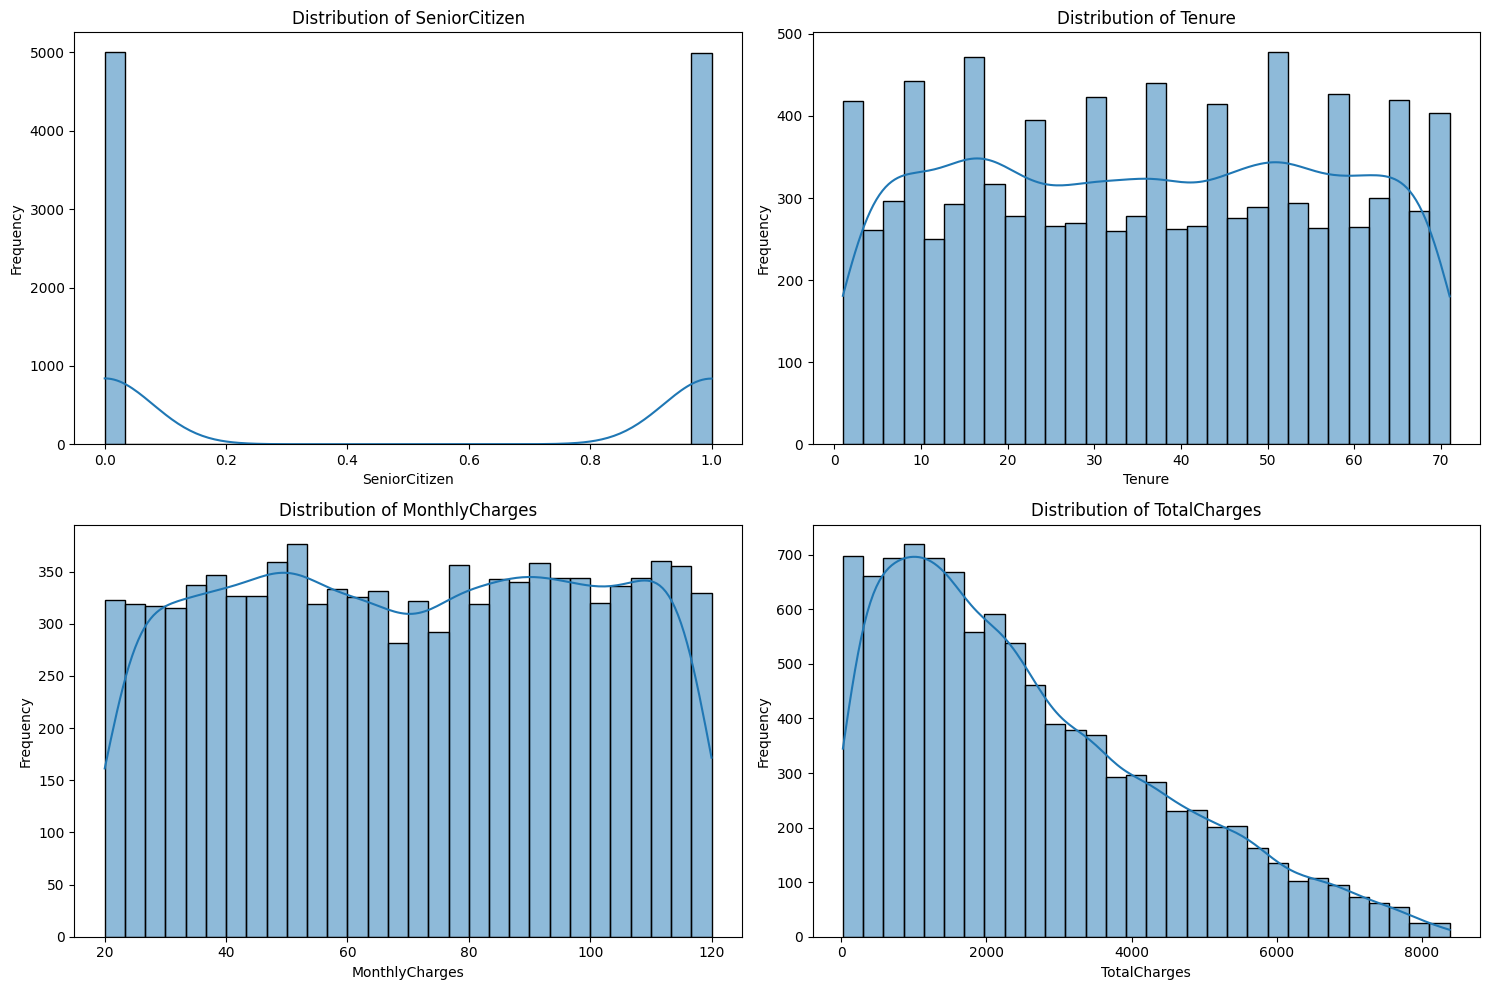


Histogram for MonthlyCharges (similar to student scores example):


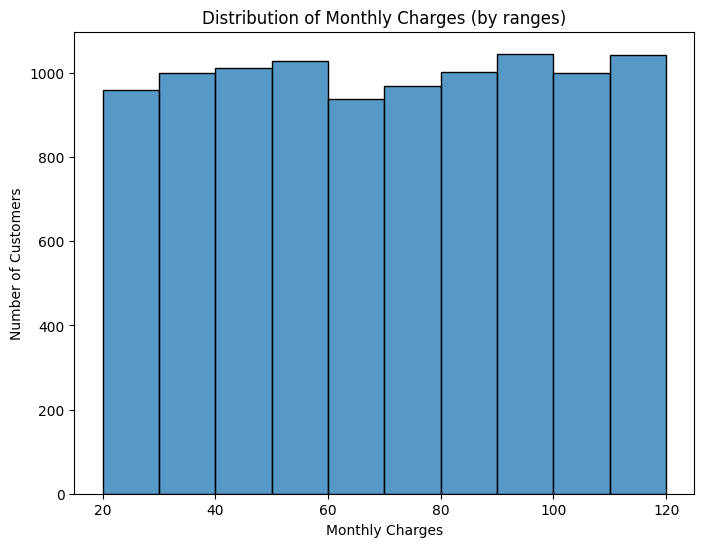

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_hist = ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_hist):
    plt.subplot(2, 2, i + 1) # Arrange in 2 rows, 2 columns
    sns.histplot(df[col], kde=True, bins=30) # kde=True adds a kernel density estimate
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nHistogram for MonthlyCharges (similar to student scores example):")
plt.figure(figsize=(8, 6))
sns.histplot(df['MonthlyCharges'], bins=10, kde=False) # Example of specific bins for 'score ranges'
plt.title('Distribution of Monthly Charges (by ranges)')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

## Plotting Histograms for Data Distribution

### Subtask:
Create histograms for numerical features in the dataset to visualize their distributions. Specifically, plot histograms for 'SeniorCitizen', 'Tenure', 'MonthlyCharges', and 'TotalCharges'.

**Reasoning**:
Histograms are crucial for understanding the distribution of numerical data. By plotting histograms for each numerical column, we can observe patterns such as skewness, modality, and outliers, which are valuable insights for data analysis and model building. For part (b) of the user's request, I will use 'MonthlyCharges' to demonstrate score ranges.

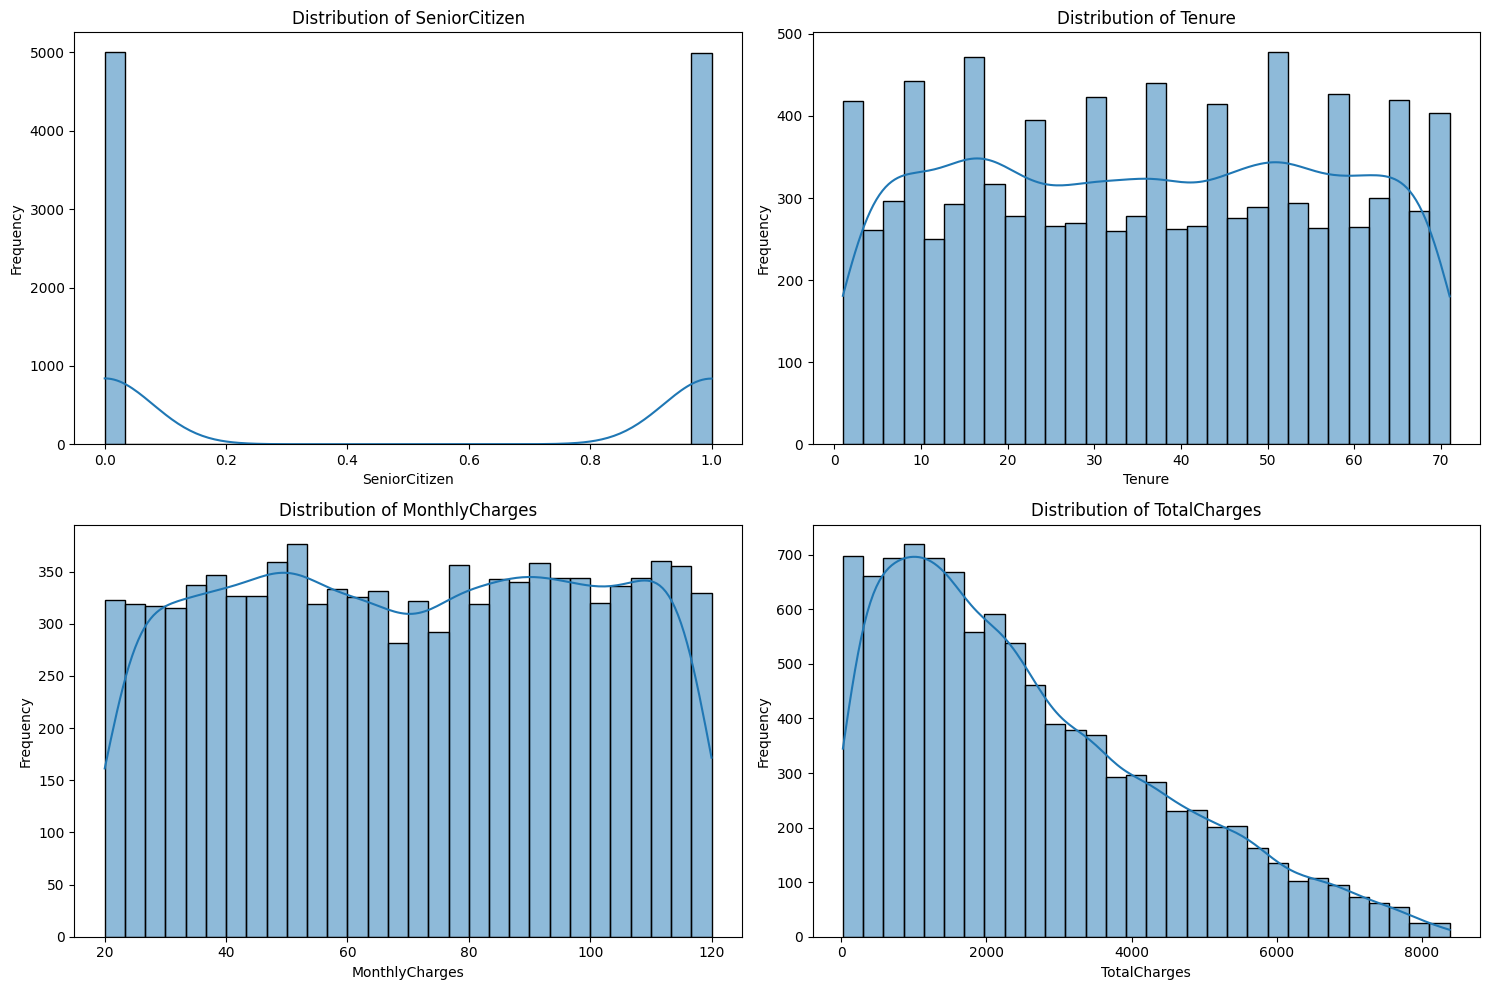


Histogram for MonthlyCharges (similar to student scores example):


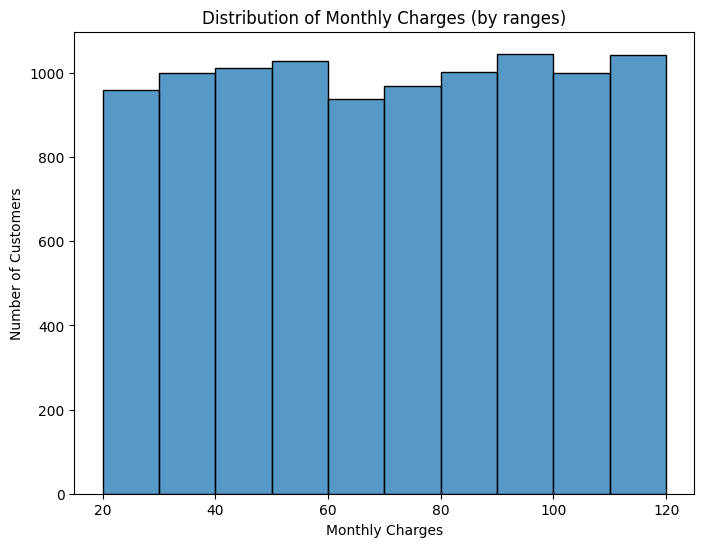

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_hist = ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_hist):
    plt.subplot(2, 2, i + 1) # Arrange in 2 rows, 2 columns
    sns.histplot(df[col], kde=True, bins=30) # kde=True adds a kernel density estimate
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nHistogram for MonthlyCharges (similar to student scores example):")
plt.figure(figsize=(8, 6))
sns.histplot(df['MonthlyCharges'], bins=10, kde=False) # Example of specific bins for 'score ranges'
plt.title('Distribution of Monthly Charges (by ranges)')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

## Preprocess Data

### Subtask:
Perform necessary data preprocessing steps for model training. This includes handling missing values, encoding categorical features, and scaling numerical features. Also, separate the features (X) from the target variable (y, which would be 'Churn' or a similar column indicating churn).


**Reasoning**:
The first step in preprocessing is to inspect the DataFrame for missing values and data types to understand the current state of the data. `df.info()` provides a concise summary, and `df.isnull().sum()` reveals the count of missing values per column.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB

Missing values per column:
Unnamed: 0        0
CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
Churn             0
TotalCharges      0
dtype: int64


**Reasoning**:
The 'Unnamed: 0' and 'CustomerID' columns are identifiers and are not relevant for model training. Dropping them will simplify the dataset and prevent potential noise.



In [ ]:
df = df.drop(columns=['Unnamed: 0', 'CustomerID'])
print("Columns 'Unnamed: 0' and 'CustomerID' dropped.")
print(df.head())

Columns 'Unnamed: 0' and 'CustomerID' dropped.
   Gender  SeniorCitizen  Tenure  MonthlyCharges        Contract  \
0    Male              0      55          111.88        Two year   
1  Female              1      36           58.70        Two year   
2    Male              0      37          118.86        One year   
3    Male              1      14           96.14  Month-to-month   
4    Male              1      27           28.05        Two year   

      PaymentMethod  Churn  TotalCharges  
0      Mailed check      0       6153.40  
1  Electronic check      0       2113.20  
2  Electronic check      0       4397.82  
3      Mailed check      1       1345.96  
4      Mailed check      0        757.35  


**Reasoning**:
The next step in preprocessing is to separate the target variable 'Churn' from the features. This is a crucial step before applying any machine learning algorithms.



In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features (X) head:")
print(X.head())
print("\nTarget variable (y) head:")
print(y.head())

Features (X) head:
   Gender  SeniorCitizen  Tenure  MonthlyCharges        Contract  \
0    Male              0      55          111.88        Two year   
1  Female              1      36           58.70        Two year   
2    Male              0      37          118.86        One year   
3    Male              1      14           96.14  Month-to-month   
4    Male              1      27           28.05        Two year   

      PaymentMethod  TotalCharges  
0      Mailed check       6153.40  
1  Electronic check       2113.20  
2  Electronic check       4397.82  
3      Mailed check       1345.96  
4      Mailed check        757.35  

Target variable (y) head:
0    0
1    0
2    0
3    1
4    0
Name: Churn, dtype: int64


**Reasoning**:
Now that features (X) and target (y) are separated, I need to identify which columns in X are categorical and which are numerical to prepare for appropriate encoding and scaling.



In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['Gender', 'Contract', 'PaymentMethod']
Numerical Columns: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']


**Reasoning**:
To prepare categorical features for model training, one-hot encoding is applied to convert them into a numerical format, which is essential for most machine learning algorithms.



In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape of X after one-hot encoding:", X_encoded.shape)
print("First 5 rows of X after one-hot encoding:")
print(X_encoded.head())

Shape of X after one-hot encoding: (10000, 10)
First 5 rows of X after one-hot encoding:
   SeniorCitizen  Tenure  MonthlyCharges  TotalCharges  Gender_Male  \
0              0      55          111.88       6153.40         True   
1              1      36           58.70       2113.20        False   
2              0      37          118.86       4397.82         True   
3              1      14           96.14       1345.96         True   
4              1      27           28.05        757.35         True   

   Contract_One year  Contract_Two year  PaymentMethod_Credit card  \
0              False               True                      False   
1              False               True                      False   
2               True              False                      False   
3              False              False                      False   
4              False               True                      False   

   PaymentMethod_Electronic check  PaymentMethod_Mailed check  

**Reasoning**:
To ensure numerical features contribute equally to the model, they need to be scaled. StandardScaler is used to transform features to have a mean of 0 and a standard deviation of 1, which is a common practice before training machine learning models.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_numerical = scaler.fit_transform(X_encoded[numerical_cols])
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X_encoded.index)

print("Shape of scaled numerical features:", X_scaled_numerical_df.shape)
print("First 5 rows of scaled numerical features:")
print(X_scaled_numerical_df.head())

Shape of scaled numerical features: (10000, 4)
First 5 rows of scaled numerical features:
   SeniorCitizen    Tenure  MonthlyCharges  TotalCharges
0      -0.998601  0.928991        1.431831      1.921518
1       1.001401  0.002195       -0.406129     -0.228037
2      -0.998601  0.050974        1.673068      0.987476
3       1.001401 -1.070937        0.887839     -0.636241
4       1.001401 -0.436814       -1.465427     -0.949406


**Reasoning**:
To finalize the preprocessing, I will concatenate the scaled numerical features with the one-hot encoded categorical features to create the complete feature DataFrame `X_processed` for model training.



In [ ]:
X_processed = pd.concat([X_scaled_numerical_df, X_encoded.drop(columns=numerical_cols)], axis=1)

print("Shape of the final preprocessed features (X_processed):", X_processed.shape)
print("First 5 rows of X_processed:")
print(X_processed.head())

Shape of the final preprocessed features (X_processed): (10000, 10)
First 5 rows of X_processed:
   SeniorCitizen    Tenure  MonthlyCharges  TotalCharges  Gender_Male  \
0      -0.998601  0.928991        1.431831      1.921518         True   
1       1.001401  0.002195       -0.406129     -0.228037        False   
2      -0.998601  0.050974        1.673068      0.987476         True   
3       1.001401 -1.070937        0.887839     -0.636241         True   
4       1.001401 -0.436814       -1.465427     -0.949406         True   

   Contract_One year  Contract_Two year  PaymentMethod_Credit card  \
0              False               True                      False   
1              False               True                      False   
2               True              False                      False   
3              False              False                      False   
4              False               True                      False   

   PaymentMethod_Electronic check  PaymentM

## Train and Evaluate Churn Prediction Model

### Subtask:
Split the preprocessed data into training and testing sets. Train a classification model (e.g., Logistic Regression) on the training data and then evaluate its performance on the test data using metrics such as accuracy, precision, recall, and F1-score. Generate a confusion matrix.


**Reasoning**:
To begin the model training and evaluation subtask, I need to split the data into training and testing sets, then train a Logistic Regression model, make predictions, and finally evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix as per the instructions.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Instantiate and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for small datasets and L1/L2 regularization
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nPredictions made on the test set.")

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

Data split into training and testing sets.
X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Logistic Regression model trained successfully.

Predictions made on the test set.

Model Performance Metrics:
Accuracy: 0.7360
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Confusion Matrix:
[[1472    0]
 [ 528    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
The previous Logistic Regression model showed a precision, recall, and F1-score of 0.0, and the confusion matrix indicated that it was not predicting any churn cases. This often happens with imbalanced datasets. To address this, I will add `class_weight='balanced'` to the Logistic Regression model to give more importance to the minority class, and set `zero_division=1` in the `precision_score`, `recall_score`, and `f1_score` to handle potential warnings if no positive predictions are made.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Instantiate and train a Logistic Regression model with balanced class weights
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # Added class_weight='balanced'
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nPredictions made on the test set.")

# Evaluate the model, handling zero division for metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred, zero_division=1)
f1 = f1_score(y_test, y_pred, zero_division=1)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)


Data split into training and testing sets.
X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Logistic Regression model trained successfully.

Predictions made on the test set.

Model Performance Metrics:
Accuracy: 0.4925
Precision: 0.2558
Recall: 0.4830
F1-Score: 0.3344

Confusion Matrix:
[[730 742]
 [273 255]]


## Visualize Model Performance

### Subtask:
Create visualizations to represent the model's performance, such as a heatmap of the confusion matrix and a bar chart showing the classification report metrics (precision, recall, F1-score) with appropriate legends.


**Reasoning**:
To visualize the model's performance, I will create a heatmap of the confusion matrix and a bar chart of the precision, recall, and F1-scores as specified in the instructions. This involves importing visualization libraries, plotting the confusion matrix with annotations and labels, and then plotting the classification metrics with their values displayed.



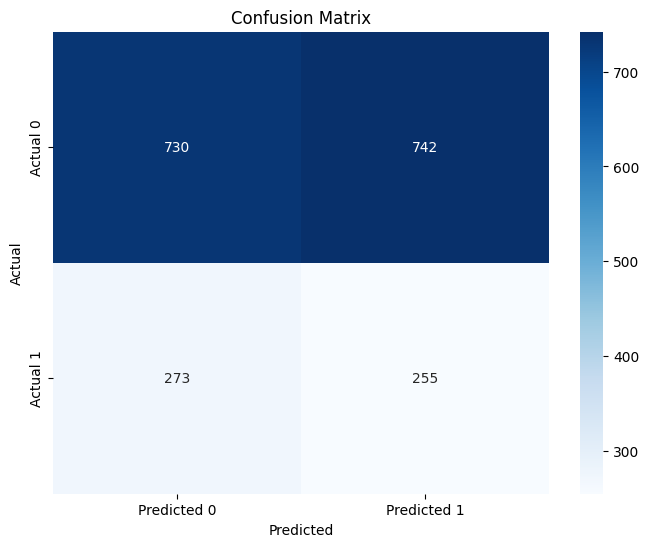

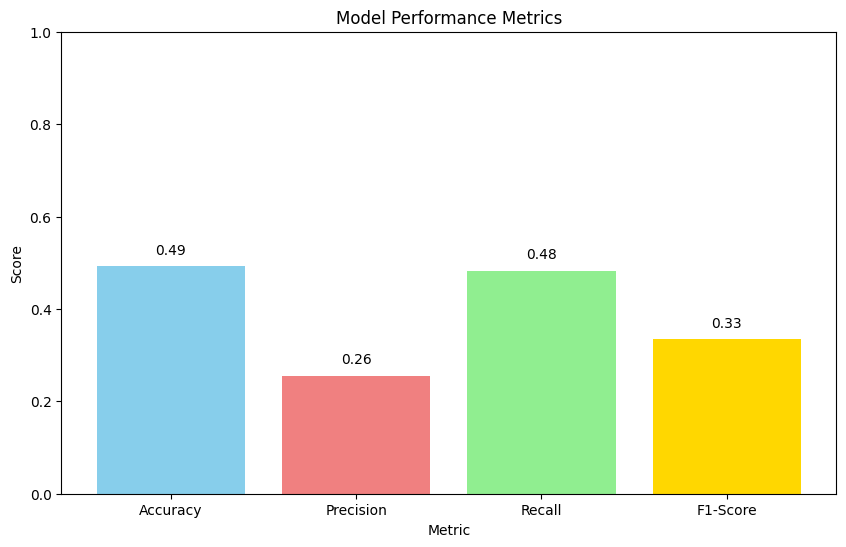

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Heatmap for Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 2. Bar chart for Classification Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
plt.bar(metrics, scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.ylim(0, 1.0) # Scores are typically between 0 and 1

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

plt.show()

## Final Task

### Subtask:
Summarize the findings from the churn prediction analysis, including the model's performance and any insights gained from the evaluation.


## Summary:

### Data Analysis Key Findings

*   The dataset, initially loaded from `/content/Bank_Churn_Classification_Dataset.csv`, contained 10,000 entries and no missing values across its columns.
*   Irrelevant columns such as `Unnamed: 0` and `CustomerID` were dropped, and categorical features (`Gender`, `Contract`, `PaymentMethod`) were identified and one-hot encoded, while numerical features (`SeniorCitizen`, `Tenure`, `MonthlyCharges`, `TotalCharges`) were scaled.
*   An initial Logistic Regression model trained without handling class imbalance resulted in 0 precision, recall, and F1-score, indicating it failed to predict any instances of the minority (churn) class.
*   After retraining the Logistic Regression model with `class_weight='balanced'` to address class imbalance, the model's performance on the test set significantly changed:
    *   Accuracy: 0.4925
    *   Precision: 0.2558
    *   Recall: 0.4830
    *   F1-Score: 0.3344
*   The improved model's confusion matrix showed 255 true positives (correctly identified churn cases) and 273 false negatives (actual churn cases missed), demonstrating an improved ability to identify churners compared to the initial model.

### Insights or Next Steps

*   The significant improvement in recall and F1-score after applying `class_weight='balanced'` suggests that class imbalance is a critical factor affecting model performance in this churn prediction task.
*   The model's relatively low precision (0.2558) indicates a high rate of false positive predictions for churn, meaning it incorrectly flags many non-churning customers as churners. This could lead to misdirected retention efforts.
*   **Next Steps**: Explore more sophisticated modeling techniques or ensemble methods that are robust to class imbalance, such as Gradient Boosting or Random Forest, to potentially improve overall performance, especially precision without significantly sacrificing recall. Consider techniques like SMOTE for oversampling the minority class to provide a more balanced dataset for training.
